In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Dataset

data = {
    'Age':       [20, 30, 40, 45, 50, 55, 60, 65, 75, 85],
    'Net Worth': [20000, 150000, 250000, 300000, 200000,
                  250000, 500000, 800000, 1200000, 900000]
}

df = pd.DataFrame(data)
print(df.to_string(index=False))

 Age  Net Worth
  20      20000
  30     150000
  40     250000
  45     300000
  50     200000
  55     250000
  60     500000
  65     800000
  75    1200000
  85     900000


In [3]:
df.describe().round(2)

,Age,Net Worth
count,10.00,10.00
mean,52.50,457000.00
std,19.90,384333.48
min,20.00,20000.00
25%,41.25,212500.00
50%,52.50,275000.00
75%,63.75,725000.00
max,85.00,1200000.00


In [4]:
corr_matrix = df.corr()
pearson_r = corr_matrix.loc['Age', 'Net Worth']

print(f"Pearson Correlation Coefficient (r): {pearson_r:.4f}")
print()
print("Full Correlation Matrix:")
print(corr_matrix.round(4))

Pearson Correlation Coefficient (r): 0.8824

Full Correlation Matrix:
              Age  Net Worth
Age        1.0000     0.8824
Net Worth  0.8824     1.0000


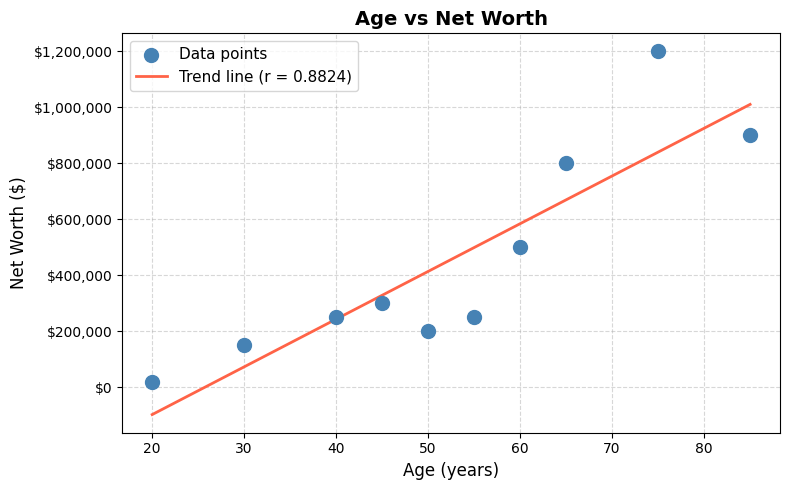

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df['Age'], df['Net Worth'], color='steelblue', s=100, zorder=5, label='Data points')

m, b = np.polyfit(df['Age'], df['Net Worth'], 1)
x_line = np.linspace(df['Age'].min(), df['Age'].max(), 200)
ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2, label=f'Trend line (r = {pearson_r:.4f})')

ax.set_title('Age vs Net Worth', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Net Worth ($)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.4f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

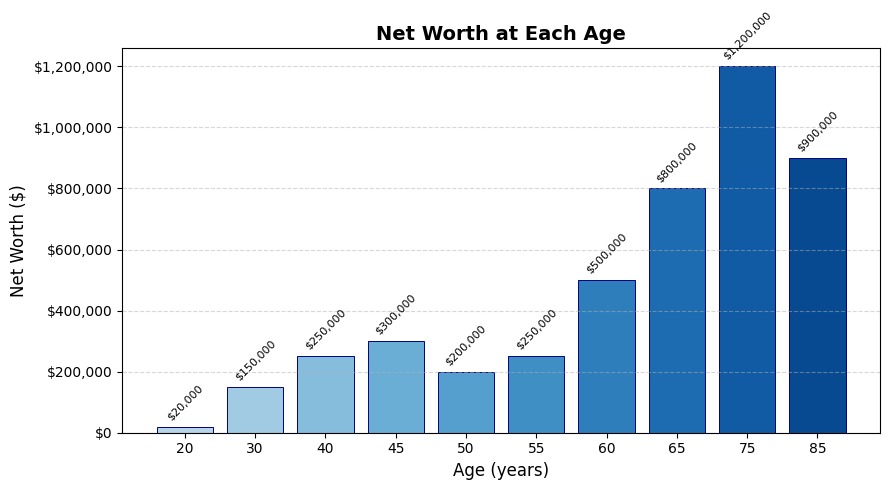

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(df)))
bars = ax.bar(df['Age'].astype(str), df['Net Worth'], color=colors, edgecolor='navy', linewidth=0.7)

for bar, val in zip(bars, df['Net Worth']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 15000,
            f'${val:,}',
            ha='center', va='bottom', fontsize=8, rotation=45)

ax.set_title('Net Worth at Each Age', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Net Worth ($)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [10]:
def interpret_correlation(r):
    abs_r = abs(r)
    direction = 'positive' if r > 0 else 'negative'
    if abs_r >= 0.9:
        strength = 'very strong'
    elif abs_r >= 0.7:
        strength = 'strong'
    elif abs_r >= 0.5:
        strength = 'moderate'
    elif abs_r >= 0.3:
        strength = 'weak'
    else:
        strength = 'very weak / negligible'
    return strength, direction

strength, direction = interpret_correlation(pearson_r)
print(f"r = {pearson_r:.4f}  →  {strength} {direction} correlation")

r = 0.8824  →  strong positive correlation
